In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *

In [71]:

def lindblad_dissipator(L, rho):
    """Lindblad Dissipator"""
    L_dag = np.conjugate(L).T
    term1 = L @ rho @ L_dag
    term2 = 0.5 * (L_dag @ L @ rho + rho @ L_dag @ L)
    return term1 - term2

# Pauli Matrices
sigma0 = np.array([[1, 0], [0, 1]], dtype=complex)
sigma1 = np.array([[0, 1], [1, 0]], dtype=complex)
sigma2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma3 = np.array([[1, 0], [0, -1]], dtype=complex)
sigma_up = (sigma1 + 1j * sigma2) / 2


In [72]:
def heat_curvature(ham_func, h_target, diss_func, params, ranges, rules, points=20):
    """Numerical solver for heat curvature"""
    # Setup Dimensions
    H_test = ham_func(ranges[0][1], ranges[1][1])
    d = H_test.shape[0]
    d2 = d**2

    # Vectorization
    basis = np.eye(d2, d2).reshape(d2, d, d)
    vec = lambda m: m.flatten()
    unvec = lambda v: v.reshape(d, d)

    def solve_l_response(L_mat, target_vec):
        aug_mat = L_mat.copy()
        aug_mat[0, :] = vec(np.identity(d))
        aug_rhs = target_vec.copy()
        aug_rhs[0] = 0
        return linsolve(aug_mat, aug_rhs)

    def get_curvature_point(p1_val, p2_val):
        """Point-wise Curvature Kernel"""
        p_vals = np.array([p1_val, p2_val])
        step = np.abs(p_vals) * 1e-4
        step[step == 0] = 1e-4

        # Steady State at Center
        H_tot = ham_func(*p_vals)
        L_mat = np.zeros((d2, d2), dtype=complex)
        for i, b in enumerate(basis):
            L_mat[:, i] = vec(-1j * (H_tot @ b - b @ H_tot) + diss_func(b)(*p_vals))
        
        ns = null_space(L_mat)
        rho_vec = ns[:, 0] if ns.shape[1] > 0 else svd(L_mat)[2][-1, :]
        rho = unvec(rho_vec / np.trace(unvec(rho_vec)))
        rho_vec = vec(rho)

        # Compute Derivatives of H and rho
        drho = np.zeros((2, d, d), dtype=complex)
        dH = np.zeros((2, d, d), dtype=complex)

        for i in range(2):
            p_step = p_vals.copy()
            p_step[i] += step[i]
            H_step = ham_func(*p_step)
            
            L_mat_step = np.zeros((d2, d2), dtype=complex)
            for j, b in enumerate(basis):
                L_mat_step[:, j] = vec(-1j * (H_step @ b - b @ H_step) + diss_func(b)(*p_step))

            dl_rho = -(L_mat_step @ rho_vec - L_mat @ rho_vec) / step[i]
            drho[i, :, :] = unvec(solve_l_response(L_mat, dl_rho))
            dH[i, :, :] = (H_step - H_tot) / step[i]

        # Curvature Formula
        return np.real(np.trace(dH[0] @ drho[1]) - np.trace(dH[1] @ drho[0]))

    # Map Generation
    p1_grid = np.linspace(ranges[0][1], ranges[0][2], points)
    p2_grid = np.linspace(ranges[1][1], ranges[1][2], points)
    
    curvature_data = np.zeros((points, points))
    for i, p1 in enumerate(p1_grid):
        for j, p2 in enumerate(p2_grid):
            curvature_data[j, i] = get_curvature_point(p1, p2)
            
    max_val = np.max(np.abs(curvature_data))
    if max_val > 0:
        curvature_data /= max_val

    return p1_grid, p2_grid, curvature_data, max_val


In [73]:
def liouvillian_gap(ham_func, diss_func, params, ranges, points=25):

    # Setup Dimensions and Vectorization
    H_test = ham_func(ranges[0][1], ranges[1][1])
    d = H_test.shape[0]
    d2 = d**2
    basis = np.eye(d2, d2, dtype=complex).reshape(d2, d, d)
    vec = lambda m: m.flatten()

    # Grid Setup
    p1_range = np.linspace(ranges[0][1], ranges[0][2], points)
    p2_range = np.linspace(ranges[1][1], ranges[1][2], points)
    gap_data = np.zeros((points, points))

    print(f"Computing Liouvillian Gap for {d}x{d} system...")

    # 3. Iterate over parameter grid and compute gap
    for i, p1 in enumerate(p1_range):
        for j, p2 in enumerate(p2_range):
            H = ham_func(p1, p2)
            
            # Construct the Liouvillian matrix
            L_mat = np.zeros((d2, d2), dtype=complex)
            for k, b in enumerate(basis):
                # Action of the Liouvillian on a basis element `b`
                L_of_b = -1j * (H @ b - b @ H) + diss_func(b)(p1, p2)
                L_mat[:, k] = vec(L_of_b)
            
            # Compute eigenvalues (eig returns tuple of (eigenvalues, eigenvectors))
            evals, _ = eigenvalues(L_mat)
            
            # The gap is the absolute value of the real part of the eigenvalue
            # with the second-largest real part (the largest is zero).
            sorted_reals = np.sort(np.real(evals))[::-1]
            gap = np.abs(sorted_reals[1])
            gap_data[j, i] = gap

    # 4. Visualization
    plt.figure(figsize=(8, 6))
    # Convert parameters from rad/s to MHz for plotting if they are frequencies
    p1_plot = p1_range / (2 * np.pi) if 'Δ' in params[0] else p1_range
    p2_plot = p2_range / (2 * np.pi) if 'Ω' in params[1] else p2_range
    
    cp = plt.contourf(p1_plot, p2_plot, gap_data, levels=20, cmap='viridis')
    plt.colorbar(cp, label='Gap')
    plt.xlabel(f"{params[0]}")
    plt.ylabel(f"{params[1]}")
    plt.title('Liouvillian Spectral Gap')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return p1_range, p2_range, gap_data


In [74]:
def compute_cycle_heats(ham_func, ham_ref, diss_func, params, rules, p_min, p_max, tau=2*np.pi, points=50):
    """Computes reversible and dissipative heat for a rectangular cycle."""
    # Setup Dimensions and Vectorization
    H_test = ham_func(*p_min)
    d = H_test.shape[0]
    d2 = d**2
    basis = np.eye(d2, d2).reshape(d2, d, d)
    vec = lambda m: m.flatten()
    unvec = lambda v: v.reshape(d, d)

    def solve_l_response(L_mat, target_vec):
        aug_mat = L_mat.copy()
        aug_mat[0, :] = vec(np.identity(d))
        aug_rhs = target_vec.copy()
        aug_rhs[0] = 0
        return linsolve(aug_mat, aug_rhs)

    def get_numerical_data(t_val):
        """Numerical Kernel with Rectangular Parameterization"""
        segment = np.floor(t_val)
        local_t = t_val % 1
        if t_val == 4.0:
            segment = 3
            local_t = 1.0

        # Handle boundary
        if segment == 0:
            p_vals = np.array([p_min[0] + local_t * (p_max[0] - p_min[0]), p_min[1]])
            vel = np.array([p_max[0] - p_min[0], 0.0])
        elif segment == 1:
            p_vals = np.array([p_max[0], p_min[1] + local_t * (p_max[1] - p_min[1])])
            vel = np.array([0.0, p_max[1] - p_min[1]])
        elif segment == 2:
            p_vals = np.array([p_max[0] - local_t * (p_max[0] - p_min[0]), p_max[1]])
            vel = np.array([-(p_max[0] - p_min[0]), 0.0])
        else: # segment == 3
            p_vals = np.array([p_min[0], p_max[1] - local_t * (p_max[1] - p_min[1])])
            vel = np.array([0.0, -(p_max[1] - p_min[1])])

        # Local Matrices
        H = ham_func(*p_vals)
        H_ref = ham_ref(*p_vals)
        
        L_mat = np.zeros((d2, d2), dtype=complex)
        for i, b in enumerate(basis):
            L_mat[:, i] = vec(-1j * (H @ b - b @ H) + diss_func(b)(*p_vals))

        # Robust Steady State extraction
        ns = null_space(L_mat)
        rho_vec = ns[:, 0] if ns.shape[1] > 0 else svd(L_mat)[2][-1, :]
        rho = unvec(rho_vec / np.trace(unvec(rho_vec)))
        rho_vec = vec(rho)
        
        # Finite Difference for d_i(rho)
        step = 1e-6
        drho = np.zeros((2, d, d), dtype=complex)
        for i in range(2):
            p_step = p_vals.copy()
            p_step[i] += step
            H_step = ham_func(*p_step)
            
            L_mat_step = np.zeros((d2, d2), dtype=complex)
            for j, b in enumerate(basis):
                L_mat_step[:, j] = vec(-1j * (H_step @ b - b @ H_step) + diss_func(b)(*p_step))
            
            dl_vec = -(L_mat_step @ rho_vec - L_mat @ rho_vec) / step
            drho[i, :, :] = unvec(solve_l_response(L_mat, dl_vec))

        # Compute Metrics
        Ai = np.array([np.real(np.trace(H_ref @ drho[i])) for i in range(2)])
        g_metric = np.array([[np.real(np.trace(drho[i] @ unvec(solve_l_response(L_mat, vec(drho[j]))))) for j in range(2)] for i in range(2)])
        
        return Ai @ vel, vel @ g_metric @ vel

    # Execution and Integration
    print(f"Starting rectangular cycle integration for d={d} system...")
    t_grid = np.linspace(0.0, 4.0, points)
    grid_data = np.array([get_numerical_data(t) for t in t_grid])
    
    t_step = 4.0 / points
    q_geo = t_step * np.sum(grid_data[:, 0])
    q_diss = (-1.0 / tau) * t_step * np.sum(grid_data[:, 1])

    print("--- Results ---")
    print(f"Geometric Heat: {q_geo}")
    print(f"Dissipated Heat: {q_diss}")
    print(f"Net: {q_geo + q_diss}")
    
    return q_geo, q_diss


## Example: 3-level Rubidium atom #
$Δ = 2π [-100, 100]$ MHz, $Ω = 2π [0, 10]$ MHz, $γd = 2π 6.1$ MHz, $γφ = 1$ MHz 

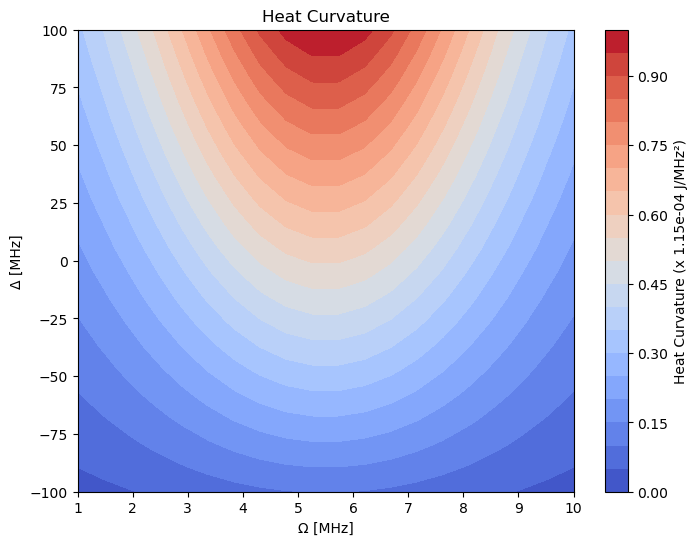

In [75]:
def HR(Delta, Omega):
    """Define the Hamiltonian"""
    Omega1 = Omega
    Omega2 = Omega
    Delta1 = Delta / 10
    Delta2 = Delta
    H = np.array([
        [0, 0, Omega1 / 2],
        [0, Delta1, Omega2 / 2],
        [Omega1 / 2, Omega2 / 2, Delta2]
    ], dtype=complex)
    return H

def LDiss1(r):
    def func(gamma_d):
        L = gamma_d * np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func

def LDiss2(r):
    def func(gamma_d):
        L = gamma_d * np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func

def LD1(r):
    def func(gamma_phi):
        L = gamma_phi * np.array([[0, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func

def LD2(r):
    def func(gamma_phi):
        L = gamma_phi * np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func

def diss(r):
    def func(Delta, Omega):
        gamma_d = 2 * np.pi * 6.1
        gamma_phi = 0.0
        return (LDiss1(r)(gamma_d) + 
                LDiss2(r)(gamma_d) + 
                LD1(r)(gamma_phi) + 
                LD2(r)(gamma_phi))
    return func

H1 = HR

p1_grid, p2_grid, curvature_data, max_val = heat_curvature(
    H1, H1, diss,
    params=['Δ', 'Ω'],
    ranges=[
        ['Δ', -2 * np.pi * 100, 2 * np.pi * 100],
        ['Ω', 2 * np.pi, 2 * np.pi * 10]
    ],
    rules={},
    points=20
)

plt.figure(figsize=(8, 6))
cp = plt.contourf(p2_grid / (2 * np.pi), p1_grid / (2 * np.pi), curvature_data, levels=20, cmap='coolwarm')
plt.colorbar(cp, label=f'Heat Curvature (x {max_val:.2e} J/MHz²)')
plt.xlabel('Ω [MHz]')
plt.ylabel('Δ [MHz]')
plt.title('Heat Curvature')
plt.savefig('3lvl_Rb.pdf')
plt.show()


Computing Liouvillian Gap for 3x3 system...


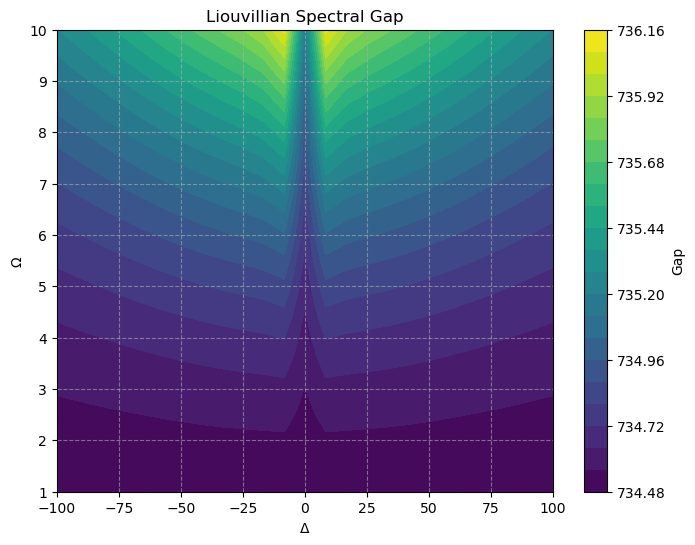

Starting rectangular cycle integration for d=3 system...
--- Results ---
Geometric Heat: 3.0897298550401366
Dissipated Heat: 1.8027110215296975e-06
Net: 3.089731657751158

Rubidium Cycle Results:
Geometric heat: 3.0897298550401366
Dissipated heat: 1.8027110215296975e-06


In [76]:
# Liouvillian Gap Example
liouvillian_gap(
    H1,
    diss,
    params=['Δ', 'Ω'],
    ranges=[
        ['Δ', -2 * np.pi * 100, 2 * np.pi * 100],
        ['Ω', 2 * np.pi, 2 * np.pi * 10]
    ],
    points=25
)

# Reversible and Dissipative Heat Example
# Cycle path goes over the whole parameter range
q_geo, q_diss = compute_cycle_heats(
    H1,
    H1,
    diss,
    params=['Δ', 'Ω'],
    rules={},
    p_min=[-2 * np.pi * 100, 2 * np.pi],
    p_max=[2 * np.pi * 100, 2 * np.pi * 10],
    tau=2 * np.pi,
    points=50
)

print(f"\nRubidium Cycle Results:")
print(f"Geometric heat: {q_geo}")
print(f"Dissipated heat: {q_diss}")

## Example: Motion-TLS Coupled System

A quantum system with a harmonic oscillator (motional degree of freedom) coupled to a two-level spin system. This represents an ion or atom with both internal (spin) and external (motional) degrees of freedom.

**Parameters:**
- Motion frequency: ω = 2π × 500 Hz
- RF frequency ω_RF ∈ [10^6, 10^7] Hz (variable parameter 1)
- Rabi frequency Ω ∈ [2π × 10, 2π × 10^4] Hz (variable parameter 2)
- Position coupling: x₀ = 10^-5 (dimensionless)
- Dissipation: γ_up = 10^3 Hz (spontaneous emission), γ_φ = 1.0 Hz (dephasing), Γ_m = 1.0 Hz (motional damping with thermal bath n = 100)

MOTION-TLS COUPLED SYSTEM ANALYSIS


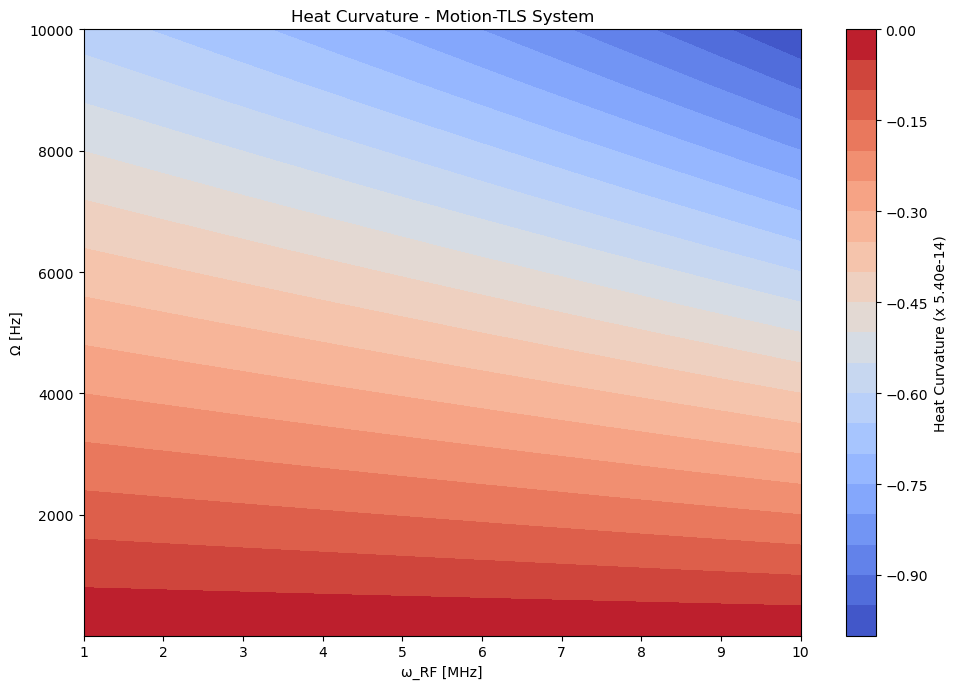

Computing Liouvillian Gap for 6x6 system...


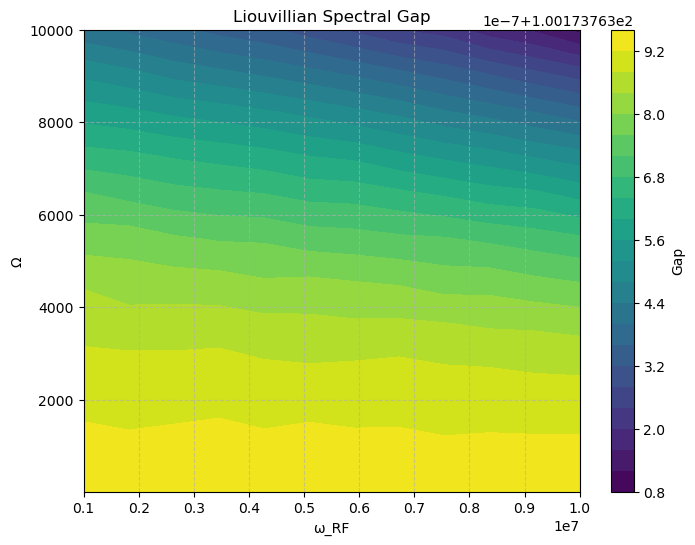

Starting rectangular cycle integration for d=6 system...
--- Results ---
Geometric Heat: 4.087432533184929e-07
Dissipated Heat: -8.837170825003178e-11
Net: 4.0865488161024284e-07

Motion-TLS Cycle Results:
Geometric heat: 4.087432533184929e-07
Dissipated heat: -8.837170825003178e-11


In [77]:
# Define operators for Motion-TLS system
N_mot = 3  # number of motional levels

# Lowering operator for motion
a_diag_vals = np.sqrt(np.arange(1, N_mot))
a = np.diag(a_diag_vals, k=1)
adag = a.T.conj()

def H_motion_tls(omega_rf, omega_rabi):
    """
    Define the Motion-TLS Hamiltonian.
    omega_rf: RF frequency (variable parameter 1)
    omega_rabi: Rabi frequency (variable parameter 2)
    """
    # Physical constants
    x0 = 1e-5  # position amplitude
    omega_mot = 2 * np.pi * 500  # motional frequency
    mu_B = 9.27e-24  # Bohr magneton
    gF = 0.5  # Landé g-factor
    B0 = 1e-3  # magnetic field
    dB = 1.0  # field gradient
    hbar = 1.05e-34  # Planck constant
    m = 1.44e-25  # particle mass (Rb-87)
    
    # Harmonic oscillator length scale
    x_ho = np.sqrt(hbar / (2 * m * omega_mot))
    eta = gF * mu_B * x_ho * dB / hbar
    delta = omega_rf - gF * mu_B * B0 / hbar
    
    # Hamiltonian components
    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 * np.kron(sigma0, adag + a))
    H_spin = 0.5 * np.kron(delta * sigma3 + omega_rabi * sigma1, np.eye(N_mot))
    H_coup = np.kron(sigma3, -eta * (adag + a))
    
    return H_mot + H_spin + H_coup


def H_motion_tls_ref(omega_rf, omega_rabi):
    """Reference Hamiltonian for heat (photon number operator)."""
    return np.kron(np.eye(2), adag @ a)


def diss_motion_tls(r):
    """Dissipator for Motion-TLS system."""
    def func(omega_rf, omega_rabi):
        gamma_up = 1e3
        gamma_phi = 1.0
        gamma_m = 1.0
        n_th = 100
        
        L_up = np.sqrt(gamma_up) * np.kron(sigma_up, np.eye(N_mot))
        L_phi = np.sqrt(gamma_phi / 2) * np.kron(sigma3, np.eye(N_mot))
        L_cool = np.sqrt(gamma_m * (n_th + 1)) * np.kron(np.eye(2), a)
        L_heat = np.sqrt(gamma_m * n_th) * np.kron(np.eye(2), adag)
        
        return (lindblad_dissipator(L_up, r) +
                lindblad_dissipator(L_phi, r) +
                lindblad_dissipator(L_cool, r) +
                lindblad_dissipator(L_heat, r))
    return func


# Run analysis for Motion-TLS system
print("=" * 60)
print("MOTION-TLS COUPLED SYSTEM ANALYSIS")
print("=" * 60)

# Heat Curvature
p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = heat_curvature(
    H_motion_tls, H_motion_tls_ref, diss_motion_tls,
    params=['ω_RF', 'Ω'],
    ranges=[
        ['ω_RF', 1e6, 1e7],
        ['Ω', 2 * np.pi * 10, 2 * np.pi * 1e4]
    ],
    rules={},
    points=12
)

# Plot Heat Curvature
plt.figure(figsize=(10, 7))
cp = plt.contourf(p1_grid_mtls / 1e6, p2_grid_mtls / (2 * np.pi), 
                    curvature_mtls, levels=20, cmap='coolwarm')
plt.colorbar(cp, label=f'Heat Curvature (x {max_val_mtls:.2e})')
plt.xlabel('ω_RF [MHz]')
plt.ylabel('Ω [Hz]')
plt.title('Heat Curvature - Motion-TLS System')
plt.tight_layout()
plt.show()

# Liouvillian Gap
liouvillian_gap(
    H_motion_tls,
    diss_motion_tls,
    params=['ω_RF', 'Ω'],
    ranges=[
        ['ω_RF', 1e6, 1e7],
        ['Ω', 2 * np.pi * 10, 2 * np.pi * 1e4]
    ],
    points=12
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_motion_tls,
    H_motion_tls_ref,
    diss_motion_tls,
    params=['ω_RF', 'Ω'],
    rules={},
    p_min=[1e6, 2 * np.pi * 10],
    p_max=[1e7, 2 * np.pi * 1e4],
    tau=2 * np.pi,
    points=30
)

print(f"\nMotion-TLS Cycle Results:")
print(f"Geometric heat: {q_geo_mtls}")
print(f"Dissipated heat: {q_diss_mtls}")